In [18]:
import torch
import torch.nn as nn

from mcap_ros2.reader import read_ros2_messages
import pandas as pd

import numpy as np
from scipy.spatial.transform import Rotation as R

bag_paths = ['train_bag_johnny/train_bag_johnny_0.mcap','train_bag_dio/train_bag_dio_0.mcap','train_bag_gyro/train_bag_gyro_0.mcap','val_bag_illumi/val_bag_illumi_0.mcap','train_bag_ash/train_bag_ash_0.mcap','train_bag_karate/train_bag_karate_0.mcap','train_bag_leave/train_bag_leave_0.mcap','train_bag_well/train_bag_well_0.mcap','train_bag_heart/train_bag_heart_0.mcap','train_bag_crtlx/train_bag_crtlx_0.mcap','train_bag_billy/train_bag_billy_0.mcap']
val_paths = ['test_bag_calyrex/test_bag_calyrex_0.mcap']
test_paths = ['test_bag_calyrex/test_bag_calyrex_0.mcap']
SCAN_MAX = 12.0 # Set to max lidar range or number close but greater than the max

In [119]:
def get_data(bag_paths):
    df_list = []
    for bag_path in bag_paths:
        rows = []
        reader = read_ros2_messages(bag_path)
        
        for msg_out in reader:
            topic = msg_out.channel.topic
            msg = msg_out.ros_msg
            t = msg_out.publish_time_ns

            if topic == '/imu':
                rows.append({'time': t, 'type': 'imu', 'val': [msg.linear_acceleration.x, msg.linear_acceleration.y, msg.linear_acceleration.z, msg.angular_velocity.x, msg.angular_velocity.y, msg.angular_velocity.z]})
            elif topic == '/scan':
                rows.append({'time': t, 'type': 'scan', 'val': list(msg.ranges)})
            elif topic == "/odom":
                ori = msg.pose.pose.orientation
                pos = msg.pose.pose.position
                #vel = msg.twist.twist.linear
                yaw = R.from_quat([ori.x, ori.y, ori.z, ori.w]).as_euler('xyz')[2]
                rows.append({'time': t, 'type': 'odom', 'val': [pos.x, pos.y, yaw]})

                #pos.x, pos.y, pos.z, ori.x, ori.y, ori.z, ori.w

        df_list.append(pd.DataFrame(rows))
    return df_list

In [137]:
def merge_times(df_list):
    synced_dfs = []
    for i in range(len(df_list)):
        df = df_list[i]
        
        df_scan = df[df['type'] == 'scan'].copy()
        df_imu = df[df['type'] == 'imu'].copy()

        df_odom = df[df['type'] == 'odom'].copy()

        df_gt = df[df['type'] == 'pose'].copy()

        df_scan = df_scan.sort_values("time")
        df_imu = df_imu.sort_values("time")
        df_odom = df_odom.sort_values("time")

        synced_df = pd.merge_asof(df_scan, df_imu, on = 'time', direction = "nearest", suffixes= ("_scan", "_imu") )
        synced_df = pd.merge_asof(synced_df, df_odom, on = 'time', direction = "nearest", suffixes= ("", "_odom") )

        
        synced_df = synced_df.dropna()
        synced_df = synced_df.iloc[::100, :].copy()

        abs_coords = np.array(synced_df['val'].tolist())
        synced_df['x_abs'] = abs_coords[:, 0]
        synced_df['y_abs'] = abs_coords[:, 1]
        synced_df['yaw'] = abs_coords[:, 2]

        synced_df['dx'] = synced_df['x_abs'].diff().fillna(0)
        synced_df['dy'] = synced_df['y_abs'].diff().fillna(0)

        yaws = synced_df['yaw'].values
        synced_df['dx'] = np.cos(-yaws) * synced_df['dx'] - np.sin(-yaws) * synced_df['dy']
        synced_df['dy'] = np.sin(-yaws) * synced_df['dx'] + np.cos(-yaws) * synced_df['dy']

        step_distances = np.sqrt(synced_df['dx']**2 + synced_df['dy']**2)

        total_distance_m = step_distances.sum()

        min_displacement = 0.01  # meters, adjust as needed

        synced_df = synced_df[step_distances >= min_displacement].copy()

        print(f"Total Distance Traveled: {total_distance_m:.3f} meters")
        print(f"Total Distance Traveled: {total_distance_m * 1000:.1f} mm")
        
        synced_dfs.append(synced_df)
    return synced_dfs

The data will be offset depending on where the sensors were placed on the robot. This data is stored in the /tf_static topic. We will get the static_tf data and later use it to center our sensor data.

In [131]:
def get_static_tf(bag_path):
    reader = read_ros2_messages(bag_path)

    for msg_out in reader:
        if msg_out.channel.topic == '/tf_static':
            msg = msg_out.ros_msg
            
            for transform in msg.transforms:
                cid = transform.child_frame_id
                t = transform.transform.translation
                r = transform.transform.rotation
                
                if cid == 'rplidar_link':
                    print(f"Laser Offset: x={t.x}, y={t.y}, z={t.z}")
                    print(f"Laser Quat: x={r.x}, y={r.y}, z={r.z}, w={r.w}")
                
                elif cid == 'imu_link':
                    print(f"IMU Offset: x={t.x}, y={t.y}, z={t.z}")
                    print(f"IMU Quat: x={r.x}, y={r.y}, z={r.z}, w={r.w}")
            
            break
      

In [132]:
get_static_tf(bag_paths[0]) # all bags use same tf so we will just choose the 1st one.

In [133]:

LASER_OFFSET_X,LASER_OFFSET_Y,LASER_OFFSET_Z  = -0.04,0.0,0.098715 # replace values with the printed values of "Laser Offset: ..."
LASER_ROT = [0, 0, 0.7071067811865475, 0.7071067811865476] # replace values with the printed values of "Laser Quat: ..."

IMU_OFFSET_X,IMU_OFFSET_Y,IMU_OFFSET_Z  = 0.050613,0.043673,0.0844 # replace values with the printed values of "IMU Offset: ..."
IMU_ROT = [0, 0, 0, 1] # replace values with the printed values of "IMU Quat: ..."

def clean_sensor_data(raw_imu, raw_scan):
    cleaned_imu = []
    cleaned_scan = []

    imu_rot = R.from_quat(IMU_ROT)
    imu_os = np.array([IMU_OFFSET_X,IMU_OFFSET_Y,IMU_OFFSET_Z])
    
    for val in raw_imu:
        accel = np.array(val[:3])
        gyro = np.array(val[3:])  
        
        cr_accel = imu_rot.apply(accel)
        cr_gyro = imu_rot.apply(gyro)

        lever_arm_accel = np.cross(cr_gyro, np.cross(cr_gyro, imu_os))

        cleaned_imu.append(np.concatenate([cr_accel - lever_arm_accel, cr_gyro]))

    num_scan = len(raw_scan[0])
    angles = np.linspace(0, 2 * np.pi, num_scan)
    laser_rot = R.from_quat(LASER_ROT)

    for val in raw_scan:
        ranges = np.array(val)
        ranges = np.where(np.isinf(ranges), SCAN_MAX, ranges) 

        sensor_points = np.zeros((num_scan,3))
        sensor_points[:,0] = ranges * np.cos(angles)
        sensor_points[:,1] = ranges * np.sin(angles)
        sensor_points[:,2] = 0

        cr_points = laser_rot.apply(sensor_points)
        fixed_ranges = np.sqrt((cr_points[:,0] + LASER_OFFSET_X)**2 + (cr_points[:,1] + LASER_OFFSET_Y)**2 + (cr_points[:,2] + LASER_OFFSET_Z)**2)
        
        cleaned_scan.append(fixed_ranges)

    return np.array(cleaned_imu), np.array(cleaned_scan)

In [134]:
from numpy.lib.stride_tricks import sliding_window_view
WINDOW_SIZE = 10

def get_mean_std(df_list):
    stats = {}
    imu = np.vstack([np.array(df['val_imu'].tolist()) for df in df_list])
    stats["imu_mean"] = np.mean(imu,axis = 0)
    stats["imu_std"] = np.std(imu,axis = 0)

    odom = np.vstack([df[['dx','dy']].values for df in df_list])
    stats["odom_mean"] = np.mean(odom,axis = 0)
    stats["odom_std"] = np.std(odom,axis = 0)
    return stats

def create_tensors(df_list,stats):
    X_list, Y_list = [], []

    for synced_df in df_list:
        c_imu, c_scan = clean_sensor_data(synced_df['val_imu'].tolist(),synced_df['val_scan'].tolist())

        c_scan = np.clip(c_scan,0,SCAN_MAX)
        c_scan = c_scan/SCAN_MAX
        c_scan_diff = np.diff(c_scan, axis=0)

        eps = 1e-9
        c_imu = (c_imu - stats['imu_mean']) / (stats['imu_std'] + eps)

        X = np.hstack([c_scan,c_imu])
        Y = (np.array(synced_df[['dx','dy']]) - stats['odom_mean']) / (stats['odom_std'] + eps)

        X_3d = sliding_window_view(X,window_shape = WINDOW_SIZE, axis = 0)
        X_3d = X_3d.transpose(0,2,1)

        Y = Y[WINDOW_SIZE-1:]

        X_list.append(torch.tensor(X_3d, dtype=torch.float32))
        Y_list.append(torch.tensor(Y, dtype=torch.float32))

    return torch.cat(X_list, dim=0), torch.cat(Y_list, dim=0)
    

In [135]:
df_list = get_data(bag_paths)
df_list[0]

,time,type,val
0,1777746300575783714,scan,"[1.7204079627990723, 1.7205132246017456, 1.720..."
1,1777746300627065806,scan,"[1.7204079627990723, 1.7205132246017456, 1.720..."
2,1777746300629832214,imu,"[0.043131959738072156, -8.28861137486746e-08, ..."
3,1777746300696549047,scan,"[1.7204079627990723, 1.7205132246017456, 1.720..."
4,1777746300706235647,imu,"[0.043131959778896965, -8.293219157868275e-08,..."
...,...,...,...
36998,1777746618605117872,odom,"[-5.228050365837176, -2.356353811071787, -1.64..."
36999,1777746618612690509,imu,"[0.043131960020346506, -8.29321573473823e-08, ..."
37000,1777746618616421070,scan,"[3.0136916637420654, 3.0143990516662598, 3.015..."
37001,1777746618629540020,odom,"[-5.228050365837176, -2.356353811071787, -1.64..."


In [138]:
df_list = merge_times(df_list)
df_list[0]

Total Distance Traveled: 55.034 meters
Total Distance Traveled: 55034.5 mm
Total Distance Traveled: 68.577 meters
Total Distance Traveled: 68577.5 mm
Total Distance Traveled: 84.296 meters
Total Distance Traveled: 84296.4 mm
Total Distance Traveled: 11.521 meters
Total Distance Traveled: 11520.8 mm
Total Distance Traveled: 51.625 meters
Total Distance Traveled: 51625.5 mm
Total Distance Traveled: 41.753 meters
Total Distance Traveled: 41753.0 mm
Total Distance Traveled: 64.159 meters
Total Distance Traveled: 64159.2 mm
Total Distance Traveled: 42.432 meters
Total Distance Traveled: 42431.9 mm
Total Distance Traveled: 57.105 meters
Total Distance Traveled: 57104.9 mm
Total Distance Traveled: 78.537 meters
Total Distance Traveled: 78536.6 mm
Total Distance Traveled: 16.015 meters
Total Distance Traveled: 16015.0 mm


,time,type_scan,val_scan,type_imu,val_imu,type,val,x_abs,y_abs,yaw,dx,dy
400,1777746310548578604,scan,"[1.7311204671859741, 1.7312265634536743, 1.731...",imu,"[0.04266003550350043, -8.280621403683152e-08, ...",odom,"[-0.26069579999072345, -1.174876054499785e-11,...",-0.260696,-1.174876e-11,9.056037e-11,-0.260696,1.185995e-11
500,1777746313029162684,scan,"[8.3206148147583, inf, inf, inf, inf, inf, inf...",imu,"[0.25076963897614507, -0.4596953239253549, 9.7...",odom,"[-0.3983874757093088, -0.0005994083256615815, ...",-0.398387,-5.994083e-04,1.188004e+00,-0.051986,4.799924e-02
600,1777746317015758983,scan,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...",imu,"[0.04313082783693778, -4.161912551435461e-08, ...",odom,"[-0.29285410947123713, 0.42418324021036863, 1....",-0.292854,4.241832e-01,1.328239e+00,0.437696,-3.228561e-01
700,1777746319484522797,scan,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...",imu,"[0.04313195443177618, -3.785004173744643e-08, ...",odom,"[-0.17533262553689194, 0.8991541016675572, 1.3...",-0.175333,8.991541e-01,1.328239e+00,0.489294,-3.608896e-01
800,1777746321948011867,scan,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...",imu,"[0.04309211313045698, -6.3415064680042194e-06,...",odom,"[-0.07115730727969166, 1.3201855506802442, 1.3...",-0.071157,1.320186e+00,1.328239e+00,0.433728,-3.199057e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
11500,1777746595568143954,scan,"[11.091337203979492, 11.052506446838379, 11.03...",imu,"[-1.113849049176873, -0.5319247987195359, 9.80...",odom,"[-4.291788795666603, -1.4778201846063501, -1.9...",-4.291789,-1.477820e+00,-1.939652e+00,0.419006,5.509221e-01
11600,1777746598072297207,scan,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...",imu,"[0.043129931721290427, -8.355469738930105e-08,...",odom,"[-4.5757171662056235, -1.7133400408525628, -2....",-4.575717,-1.713340e+00,-2.449829e+00,0.368897,4.166970e-01
11700,1777746600434955367,scan,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...",imu,"[0.043131950449868825, -8.06723053779373e-08, ...",odom,"[-4.951826446141266, -2.024873228336358, -2.44...",-4.951826,-2.024873e+00,-2.449829e+00,0.488376,5.514519e-01
11800,1777746602878404288,scan,"[3.018190383911133, 3.016291856765747, 3.01561...",imu,"[0.42772737248175885, -0.3924531505054406, 9.7...",odom,"[-5.220624767608032, -2.2501333184322254, -1.6...",-5.220625,-2.250133e+00,-1.679329e+00,0.253051,2.759619e-01


In [139]:
for i, df in enumerate(df_list):
    print(f"Bag {i} - dx mean: {df['dx'].mean():.5f}, dy mean: {df['dy'].mean():.5f}")
    print(f"Bag {i} - dx std: {df['dx'].std():.5f}, dy std: {df['dy'].std():.5f}")

Bag 0 - dx mean: 0.38557, dy mean: -0.00509
Bag 0 - dx std: 0.17165, dy std: 0.34480
Bag 1 - dx mean: 0.41303, dy mean: -0.02708
Bag 1 - dx std: 0.15143, dy std: 0.41416
Bag 2 - dx mean: 0.38800, dy mean: -0.15249
Bag 2 - dx std: 0.15572, dy std: 0.30981
Bag 3 - dx mean: 0.39365, dy mean: -0.08286
Bag 3 - dx std: 0.13710, dy std: 0.14195
Bag 4 - dx mean: 0.41172, dy mean: -0.01289
Bag 4 - dx std: 0.15470, dy std: 0.42057
Bag 5 - dx mean: 0.43816, dy mean: 0.27663
Bag 5 - dx std: 0.11034, dy std: 0.31573
Bag 6 - dx mean: 0.42538, dy mean: 0.01524
Bag 6 - dx std: 0.14513, dy std: 0.33790
Bag 7 - dx mean: 0.40305, dy mean: -0.13114
Bag 7 - dx std: 0.18138, dy std: 0.23331
Bag 8 - dx mean: 0.43489, dy mean: -0.06213
Bag 8 - dx std: 0.11914, dy std: 0.35040
Bag 9 - dx mean: 0.39696, dy mean: -0.00889
Bag 9 - dx std: 0.18600, dy std: 0.26800
Bag 10 - dx mean: 0.33806, dy mean: 0.13394
Bag 10 - dx std: 0.18254, dy std: 0.32858


In [156]:
stats = get_mean_std(df_list)
X_train, Y_train = create_tensors(df_list,stats)

val_df = get_data(val_paths)
val_df = merge_times(val_df)
X_val, Y_val = create_tensors(val_df,stats)

test_df = get_data(test_paths)
test_df = merge_times(test_df)
X_test, Y_test = create_tensors(test_df,stats)

Total Distance Traveled: 21.263 meters
Total Distance Traveled: 21262.6 mm
Total Distance Traveled: 21.263 meters
Total Distance Traveled: 21262.6 mm


In [157]:
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")  
print(f"X_test: {X_test.shape}")

X_train: torch.Size([992, 10, 646])
X_val: torch.Size([34, 10, 646])
X_test: torch.Size([34, 10, 646])


In [158]:
class MLocLSTM(nn.Module):
    def __init__(self,input_size,hidden_size,output_size,dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size,hidden_size, batch_first = True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self,x):
        out, _ = self.lstm(x)

        p_short_term  = out[:,-1,:]
        prediction = self.fc(p_short_term)
        return prediction

In [159]:
model = MLocLSTM(input_size = 646, hidden_size = 64, output_size = 2, dropout = 0.8)
loss_type = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [155]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


for epoch in range(200):
    model.train()
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_type(output, Y_batch)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            v_output = model(X_val)
            v_loss = loss_type(v_output,Y_val)

            y_pred = (v_output.cpu().numpy() * stats['odom_std']) + stats['odom_mean']
            y_true = (Y_val.cpu().numpy() * stats['odom_std']) + stats['odom_mean']
            
            pred_step_distances = np.sqrt(y_pred[:, 0]**2 + y_pred[:, 1]**2)
            total_pred_distance = pred_step_distances.sum()

            print(f"Model Predicted Distance: {total_pred_distance:.3f} meters")
            mae_mm = np.mean(np.abs(y_pred - y_true)) * 1000

        print(f"Epoch {epoch}, Train Loss: {loss.item():.6f} , Val Loss:{v_loss.item():.6f}, val mae: {mae_mm:.2f} mm")

Model Predicted Distance: 14.700 meters
Epoch 0, Train Loss: 1.042893 , Val Loss:0.862601, val mae: 220.20 mm
Model Predicted Distance: 16.017 meters
Epoch 10, Train Loss: 0.554823 , Val Loss:1.093556, val mae: 246.24 mm
Model Predicted Distance: 15.841 meters
Epoch 20, Train Loss: 0.268542 , Val Loss:1.290406, val mae: 260.91 mm
Model Predicted Distance: 16.825 meters
Epoch 30, Train Loss: 0.217374 , Val Loss:1.399561, val mae: 272.77 mm
Model Predicted Distance: 17.744 meters
Epoch 40, Train Loss: 0.167280 , Val Loss:1.507426, val mae: 277.11 mm
Model Predicted Distance: 17.907 meters
Epoch 50, Train Loss: 0.108966 , Val Loss:1.519306, val mae: 278.36 mm
Model Predicted Distance: 18.882 meters
Epoch 60, Train Loss: 0.058587 , Val Loss:1.702442, val mae: 296.43 mm
Model Predicted Distance: 19.345 meters
Epoch 70, Train Loss: 0.052965 , Val Loss:1.710860, val mae: 297.26 mm
Model Predicted Distance: 18.739 meters
Epoch 80, Train Loss: 0.047295 , Val Loss:1.764573, val mae: 308.71 mm
Mo

In [154]:
model.eval()
with torch.no_grad():
    print(stats['odom_std'])
    test_output = model(X_test)
    test_pred_m = (test_output.cpu().numpy() * stats['odom_std']) + stats['odom_mean']
    test_true_m = (Y_test.cpu().numpy() * stats['odom_std']) + stats['odom_mean']
    
    test_mae_mm = np.mean(np.abs(test_pred_m - test_true_m)) * 1000
    print(f"\nFINAL TEST RESULTS | MAE: {test_mae_mm:.2f} mm")

[0.15824454 0.34538531]

FINAL TEST RESULTS | MAE: 229.46 mm


Final position error: 11.184m


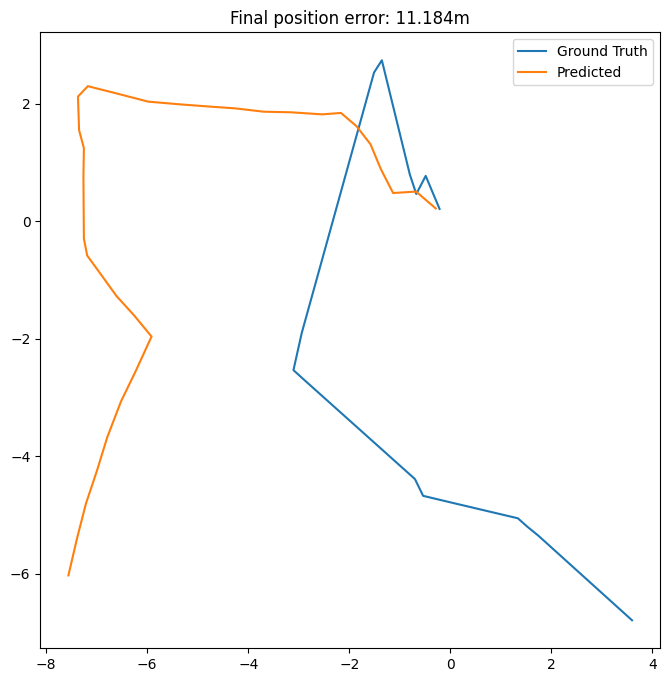

In [176]:
def evaluate_trajectory(y_pred, y_true, val_df, stats):
    # Denormalize
    pred = (y_pred * stats['odom_std']) + stats['odom_mean']
    true = (y_true * stats['odom_std']) + stats['odom_mean']
    
    yaws = val_df[0]['yaw'].values[WINDOW_SIZE-1:] 

    pred_mag = np.sqrt(pred[:,0]**2 + pred[:,1]**2)
    true_mag = np.sqrt(true[:,0]**2 + true[:,1]**2)
    scale_factor = true_mag.mean() / pred_mag.mean()
    pred = pred * scale_factor
    
    pred_world = np.zeros_like(pred)
    true_world = np.zeros_like(true)
    
    for i in range(len(pred)):
        yaw = yaws[i]
        # Rotate back to world frame
        pred_world[i,0] = np.cos(yaw) * pred[i,0] - np.sin(yaw) * pred[i,1]
        pred_world[i,1] = np.sin(yaw) * pred[i,0] + np.cos(yaw) * pred[i,1]
        true_world[i,0] = np.cos(yaw) * true[i,0] - np.sin(yaw) * true[i,1]
        true_world[i,1] = np.sin(yaw) * true[i,0] + np.cos(yaw) * true[i,1]
    
    pred_traj = np.cumsum(pred_world, axis=0)
    true_traj = np.cumsum(true_world, axis=0)
    
    final_error = np.sqrt(
        (pred_traj[-1,0] - true_traj[-1,0])**2 + 
        (pred_traj[-1,1] - true_traj[-1,1])**2
    )
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,8))
    plt.plot(true_traj[:,0], true_traj[:,1], label='Ground Truth')
    plt.plot(pred_traj[:,0], pred_traj[:,1], label='Predicted')
    plt.legend()
    plt.title(f'Final position error: {final_error:.3f}m')
    plt.savefig('trajectory_comparisohhn.png')
    
    return final_error
final_err = evaluate_trajectory(v_output.cpu().numpy(), Y_val.cpu().numpy(), val_df, stats)
print(f"Final position error: {final_err:.3f}m")